**Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

plt.style.use("ggplot")

In [2]:
file_path = "D:/Anaconda/Project/Sales Data Analysis Dashboard Project/data/Sales_Data_Analysis_Dataset_5000.csv"
df = pd.read_csv(file_path)
df.head()

,Order_ID,Order_Date,Customer_Name,State,Category,Product,Quantity,Unit_Price,Discount_%,Sales,Profit,Payment_Method
0,100001,2024-07-28,Neha,Karnataka,Furniture,Cabinet,1,1499,25,1124.25,138.74,UPI
1,100002,2024-11-17,Priya,Maharashtra,Clothing,Shoes,3,2499,5,7122.15,2477.13,Net Banking
2,100003,2025-10-19,Neha,Haryana,Furniture,Chair,4,4999,10,17996.40,5292.91,Wallet
3,100004,2024-02-29,Meera,Rajasthan,Furniture,Chair,7,9999,5,66493.35,14794.76,UPI
4,100005,2025-10-22,Vijay,Tamil Nadu,Electronics,Keyboard,8,19999,5,151992.40,39082.69,UPI


**Clean the Data**

In [3]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ","_")
df = df.drop_duplicates()

if "order_date" in df.columns:
    df["order_date"] = pd.to_datetime(df["order_date"] , errors = "coerce")

df["sales"] = pd.to_numeric(df["sales"], errors = "coerce")
df["quantity"] = pd.to_numeric(df["quantity"], errors = "coerce")

df = df.dropna(subset=["sales"])
df.head()

,order_id,order_date,customer_name,state,category,product,quantity,unit_price,discount_%,sales,profit,payment_method
0,100001,2024-07-28,Neha,Karnataka,Furniture,Cabinet,1,1499,25,1124.25,138.74,UPI
1,100002,2024-11-17,Priya,Maharashtra,Clothing,Shoes,3,2499,5,7122.15,2477.13,Net Banking
2,100003,2025-10-19,Neha,Haryana,Furniture,Chair,4,4999,10,17996.40,5292.91,Wallet
3,100004,2024-02-29,Meera,Rajasthan,Furniture,Chair,7,9999,5,66493.35,14794.76,UPI
4,100005,2025-10-22,Vijay,Tamil Nadu,Electronics,Keyboard,8,19999,5,151992.40,39082.69,UPI


**Basic Information About Table**

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_id        5000 non-null   int64         
 1   order_date      5000 non-null   datetime64[ns]
 2   customer_name   5000 non-null   object        
 3   state           5000 non-null   object        
 4   category        5000 non-null   object        
 5   product         5000 non-null   object        
 6   quantity        5000 non-null   int64         
 7   unit_price      5000 non-null   int64         
 8   discount_%      5000 non-null   int64         
 9   sales           5000 non-null   float64       
 10  profit          5000 non-null   float64       
 11  payment_method  5000 non-null   object        
dtypes: datetime64[ns](1), float64(2), int64(4), object(5)
memory usage: 468.9+ KB


**Key Performance Indicator**

In [5]:
total_sales = df["sales"].sum()
total_orders = df["order_id"].nunique() if "order_id" in df.columns else len(df)
average_order_value = total_sales / total_orders if total_orders else 0

print("Total Sales: ", total_sales)
print("Total Orders: ", total_orders)
print("Average Order Value: ", round(average_order_value, 2))

Total Sales:  90388444.64999999
Total Orders:  5000
Average Order Value:  18077.69


**Top Product**

In [6]:
top_products = df.groupby("product")["sales"].sum().sort_values(ascending=False).head(10)
top_products

product
Desk        4955656.05
Jeans       4925136.40
Jacket      4874390.90
Keyboard    4813749.95
Chair       4810865.65
Cabinet     4770732.75
Light       4767142.70
T-Shirt     4741517.35
Fan         4695966.40
Laptop      4415267.25
Name: sales, dtype: float64

**Top customers**

In [7]:
top_customers = df.groupby("customer_name")["sales"].sum().sort_values(ascending=False).head(10)
top_customers

customer_name
Neha      6757844.70
Akash     6654640.45
Pooja     6635186.50
Anjali    6347203.00
Amit      6297004.45
Vijay     6175723.60
Arjun     6014059.15
Rohan     6007621.50
Meera     5966831.25
Simran    5892799.80
Name: sales, dtype: float64

**Monthly Sales**

In [8]:
df["month"] = df["order_date"].dt.to_period("M").astype(str)
monthly_sales = df.groupby("month")["sales"].sum().reset_index()
monthly_sales

,month,sales
0,2024-01,3725088.30
1,2024-02,3584034.70
2,2024-03,3875459.40
3,2024-04,3810479.70
4,2024-05,4264891.90
5,2024-06,4239908.55
6,2024-07,3192733.70
7,2024-08,3987028.85
8,2024-09,3736213.05
9,2024-10,3417501.20


**Create charts folder**

In [9]:
os.makedirs("charts", exist_ok=True)

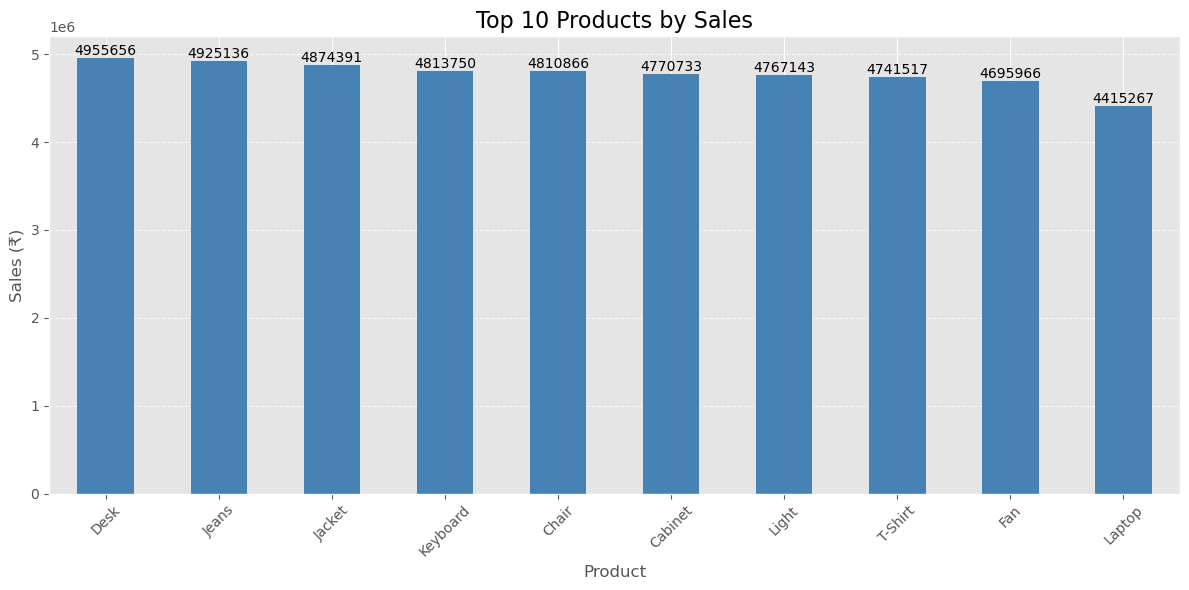

In [10]:
plt.figure(figsize=(12, 6))
ax = top_products.plot(kind="bar", figsize=(12, 6), color="steelblue")
ax.bar_label(ax.containers[0], fmt="%.0f")
plt.title("Top 10 Products by Sales", fontsize=16)
plt.xlabel("Product", fontsize=12)
plt.ylabel("Sales (₹)", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.savefig("D:/Anaconda/Project/Sales Data Analysis Dashboard Project/charts/top_products.png", dpi=300)
plt.show()

**Top Customers chart**

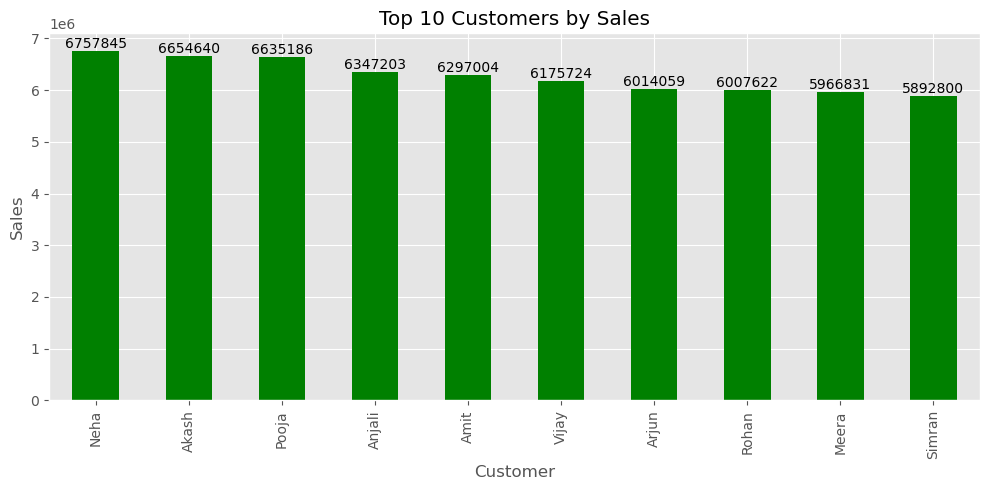

In [11]:
plt.figure(figsize=(10, 5))
ax = top_customers.plot(kind="bar", color="green", figsize=(10,5))
ax.bar_label(ax.containers[0], fmt="%.0f")
plt.title("Top 10 Customers by Sales")
plt.xlabel("Customer")
plt.ylabel("Sales")
plt.tight_layout()
plt.savefig("D:/Anaconda/Project/Sales Data Analysis Dashboard Project/charts/top_customers.png")
plt.show()

**Summary table**

In [12]:
summary = pd.DataFrame({
    "Metric": ["Total Sales", "Total Orders", "Average Order Value"],
    "Value": [total_sales, total_orders, round(average_order_value, 2)]
})

summary

,Metric,Value
0,Total Sales,90388444.65
1,Total Orders,5000.00
2,Average Order Value,18077.69
